## STOCHASTIC MODELING
MODULE 4 | LESSON 4


---


# **BCC (1997) MODEL CALIBRATION**


|  |  |
|:---|:---|
|**Reading Time** |  75 minutes |
|**Prior Knowledge** | BCC (1997), CIR (1985), Bates (1996) |
|**Keywords** | BCC (1997), Calibration |


---

In this final lesson of the module, we are going to fully calibrate the BCC (1997) model to interest rates and market prices. Arguably, we have, at one point in the course or another, performed all the different tasks required for BCC calibration. The purpose of this lesson is to actually put all these pieces together.*

As usual, let's start with importing the necessary libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.interpolate import splev, splrep
from scipy.optimize import brute, fmin

As is always the case when we have a model with distinct components that have to be calibrated to market data simultaneously, we have to start by following a sequential order. There are four general steps involved in the calibration of a BCC model:

1. Calibration of short interest rates (CIR, 1985)

2. With the short rates from step 1, global calibration of Stochastic Volatility model (Heston, 1993)

3. Using the parameters from steps 2 and 1, locally calibrate the jump component (adjusted Merton, 1976)

4. Full calibration with the previous parameters from 2 and 3 as guidance

\
Note that we are indeed establishing a clear separation between the calibration of the interest rates and the rest of the BCC model components. This is due to the assumption that the underlying asset and interest rates have zero correlation between each other.

For simplicity, we will use the same data we have been dealing with in previous model calibrations. But remember that we can do this for any dataset with market information on interest rates and underlying asset prices.


## **1. Calibration of Short Rates**

First, we will calibrate the short rate model in BCC, which is essentially the CIR (1985) model we calibrated in Lesson 2 of this very same module. For the sake of completeness, we reproduce the process here. Please go back to the Lesson 2 notebook for more detailed information on the process.

In [2]:
# Euribor Market data

mat_list = np.array((1, 7, 14, 30, 60, 90, 180, 270, 360)) / 360
rate_list = (
    np.array((-0.032, -0.013, -0.013, 0.007, 0.043, 0.083, 0.183, 0.251, 0.338)) / 100
)

In [3]:
# Capitalization factors and Zero-rates

r0 = rate_list[0]
factors = 1 + mat_list * rate_list
zero_rates = 1 / mat_list * np.log(factors)

In [4]:
# Interpolation and Forward rates

bspline = splrep(mat_list, zero_rates, k=3)  # Cubic spline
mat_list_n = np.linspace(
    0.0, 1.0, 24
)  # Create 24 equally spaced maturities between 0 and 1
inter_rates = splev(mat_list_n, bspline, der=0)  # Interpolated rates

first_der = splev(mat_list_n, bspline, der=1)  # First derivative of spline
f = (
    inter_rates + first_der * mat_list_n
)  # Forward rate given interpolated ones and first derivative

In [5]:
# CIR (1985) Forward rate function

def CIR_forward_rate(alpha):
    """
    Forward rates in CIR (1985) model
    The set of parameters is called alpha and include Kappa_r, Theta_r and Sigma_r
    """

    kappa_r, theta_r, sigma_r = alpha

    t = mat_list_n
    g = np.sqrt(kappa_r**2 + 2 * sigma_r**2)

    s1 = (kappa_r * theta_r * (np.exp(g * t) - 1)) / (
        2 * g + (kappa_r + g) * (np.exp(g * t) - 1)
    )

    s2 = r0 * (
        (4 * g**2 * np.exp(g * t)) / (2 * g + (kappa_r + g) * (np.exp(g * t)-1)) ** 2)


    return s1 + s2

In [6]:
# CIR (1985) Error function

def CIR_error_function(alpha):
    """
    Error function to calibrate CIR (1985) model
    """

    kappa_r, theta_r, sigma_r = alpha

    # Few remarks to avoid problems for certain values of parameters:
    if 2 * kappa_r * theta_r < sigma_r**2:
        return 100
    if kappa_r < 0 or theta_r < 0 or sigma_r < 0.001:
        return 100

    forward_rates = CIR_forward_rate(alpha)
    MSE = np.sum((f - forward_rates) ** 2) / len(f)

    return MSE

In [7]:
# CIR (1985) Calibration via minimizing Forward rate differences

def CIR_calibration():
    opt = fmin(
        CIR_error_function,
        [1.0, 0.02, 0.1],
        xtol=0.00001,
        ftol=0.00001,
        maxiter=300,
        maxfun=500,
    )

    return opt

And here we have the results of the calibration of CIR (1985). Of course, since we used the same market data as in the previous lessons, we get the same parameter values:

In [8]:
params_CIR = CIR_calibration()
kappa_r, theta_r, sigma_r = params_CIR
params_CIR

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 270
         Function evaluations: 485


array([0.14684901, 0.10451054, 0.17519711])

## **2. Calibration of Stochastic Volatility Component (Heston, 1993)**

Next, we will take the calibrated CIR model parameters as inputs and essentially perform a calibration process similar to the one we implemented for the Bates (1996) model. Once again, we will focus on the same market data (i.e., options on EuroStoxx 50), so the calibration process should be pretty similar to the one we performed in previous modules. Please refer to these modules for further explanation of specific steps if needed.

### 2.1. Load Market Data

The first step is to load options market data to be used in the calibration:

In [9]:
# Option market data loading

h5 = pd.HDFStore("option_data_wqu.h5", "r")
data = h5["data"]  # European call & put option data (3 maturities)
h5.close()
S0 = 3225.93  # EURO STOXX 50 level 30.09.2014

In [10]:
# Option Selection

tol = 0.02  # Tolerance level to select ATM options (percent around ITM/OTM options)
options = data[(np.abs(data["Strike"] - S0) / S0) < tol]
options = options.copy()
options["Date"] = pd.to_datetime(options["Date"])
options["Maturity"] = pd.to_datetime(options["Maturity"])

Note that the code is prepared to deal with all maturities in the data at the same time. However, this would imply that we are looking for parameters in our calibration such that our model is able to replicate, with the same parameters, all the maturities we observed. Obviously, this introduces a fitting problem because it is much harder to perfectly match option market prices for different maturities under a constant set of parameters. You are welcome to modify the code and try to match the 3 maturities in the example dataset at the same time. You will see that the calibration process does not do such a good job.

However, when you try to calibrate the model to a single maturity, the fit of the model improves drastically. We are going to show you that in this notebook for the closest maturity we observe in the market:

In [11]:
mats = sorted(set(options["Maturity"]))
options = options[options["Maturity"] == mats[0]]

### 2.2. Add Time to Maturity and Short Rates

Now, for each option in the market, we calculate its maturity and associated short rate given the CIR (1985) calibration parameters. This requires that, first, we need to incorporate our ZCB pricing functions from CIR.

In [12]:
# ZCB pricing functions under CIR (1985)


def gamma(kappa_r, sigma_r):
    """
    Gamma function in CIR (1985)
    """
    return np.sqrt(kappa_r**2 + 2 * sigma_r**2)


def b1(alpha):
    """
    b1 function in CIR (1985)
    alpha is the parameter set
    """
    r0, kappa_r, theta_r, sigma_r, t, T = alpha
    g = gamma(kappa_r, sigma_r)
    x = (
        (2 * g * np.exp((kappa_r + g) * (T - t) / 2))
        / (2 * g + (kappa_r + g) * (np.exp(g * (T - t)) - 1))
    ) ** (2 * kappa_r * theta_r / sigma_r**2)

    return x


def b2(alpha):
    """
    b2 function in CIR (1985)
    alpha is the parameter set
    """
    r0, kappa_r, theta_r, sigma_r, t, T = alpha
    g = gamma(kappa_r, sigma_r)
    x = (2 * (np.exp(g * (T - t)) - 1)) / (
        2 * g + (kappa_r + g) * (np.exp(g * (T - t)) - 1)
    )

    return x


def B(alpha):
    """
    ZCB prices in the CIR (1985) model
    """
    b_1 = b1(alpha)
    b_2 = b2(alpha)
    r0, kappa_r, theta_r, sigma_r, t, T = alpha

    E_rt = theta_r + np.exp(-kappa_r * t) * (r0 - theta_r)

    zcb = b_1 * np.exp(-b_2 * E_rt)

    return zcb

Now, we can incorporate to each option in the market its maturity and corresponding short rate:

In [13]:
# Including short rates and time to maturity

for row, option in options.iterrows():
    T = (option["Maturity"] - option["Date"]).days / 365.0
    options.loc[row, "T"] = T
    B0T = B([r0, kappa_r, theta_r, sigma_r, 0, T])
    options.loc[row, "r"] = -np.log(B0T) / T

### 2.3. Calibration of Heston (1993)

Now, we can calibrate the stochastic volatility component of the BCC model, which as you know is essentially the Heston (1993) model calibration we performed in Module 1. Please refer there for a deeper explanation.

*Note that all this coding can be much more efficiently performed by using object-oriented programming. You are very welcome to do that and build your own library with option pricing functions. Here, for the sake of completeness, we reproduce all the functions needed in the process.*

In [14]:
i = 0
min_MSE = 500

In [15]:
def H93_error_function(p0):
    """Error function for parameter calibration via
    Lewis (2001) Fourier approach for Heston (1993).
    Parameters
    ==========
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial, instantaneous variance
    Returns
    =======
    MSE: float
        mean squared error
    """
    global i, min_MSE
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or rho < -1.0 or rho > 1.0:
        return 500.0
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 500.0
    se = []
    for row, option in options.iterrows():
        model_value = H93_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
        )
        se.append((model_value - option["Call"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 100 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    return MSE

In [16]:
def H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)

    Parameter definition:
    ==========
    S0: float
        initial stock/index level
    K: float
        strike price
    T: float
        time-to-maturity (for t=0)
    r: float
        constant risk-free short rate
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial level of variance
    Returns
    =======
    call_value: float
        present value of European call option
    """
    int_value = quad(
        lambda u: H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

In [17]:
def H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """
    Fourier-based approach for Lewis (2001): Integration function.
    """
    char_func_value = H93_char_func(
        u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0
    )
    int_func_value = (
        1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
    )
    return int_func_value

In [18]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)
    Fourier-based approach: characteristic function.
    Parameter definitions see function BCC_call_value."""
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

In [19]:
def H93_calibration_full():
    """Calibrates Heston (1993) stochastic volatility model to market quotes."""
    # First run with brute force
    # (scan sensible regions, for faster convergence)
    p0 = brute(
        H93_error_function,
        (
            (2.5, 10.6, 5.0),  # kappa_v
            (0.01, 0.041, 0.01),  # theta_v
            (0.05, 0.251, 0.1),  # sigma_v
            (-0.75, 0.01, 0.25),  # rho
            (0.01, 0.031, 0.01),
        ),  # v0
        finish=None,
    )

    # Second run with local, convex minimization
    # (we dig deeper where promising results)
    opt = fmin(
        H93_error_function, p0, xtol=0.000001, ftol=0.000001, maxiter=950, maxfun=900
    )
    return opt

Now it's time to see the first model parameters that our calibration outputs and save them for future use:

In [20]:
kappa_v, theta_v, sigma_v, rho, v0 = H93_calibration_full()

   0 | [ 2.5   0.01  0.05 -0.75  0.01] | 366.873 | 366.873
 100 | [ 2.5   0.04  0.05 -0.5   0.02] |  63.893 |   6.586
 200 | [ 7.5   0.02  0.25 -0.25  0.03] |  11.110 |   6.586
 300 | [ 1.678065    0.03263888  0.30623977 -0.9250553   0.03049744] |   4.801 |   4.627
 400 | [ 1.94180185  0.0305211   0.32400118 -0.99819954  0.03063071] |   4.163 |   4.163
 500 | [ 4.66223566  0.01516932  0.37244881 -0.98721646  0.03179907] |   3.605 |   3.605
 600 | [ 4.85054622  0.01712368  0.39369274 -0.99999864  0.03152476] |   3.335 |   3.335
 700 | [ 7.5649759   0.05282583  0.50297441 -0.99917509  0.02694977] |   2.482 |   2.482
 800 | [ 9.48946796e+01  4.07147278e-02  2.68488540e+00 -9.99001091e-01
  1.11745877e-02] |   0.101 |   0.101
 900 | [ 8.95605129e+01  4.07713146e-02  2.55083472e+00 -9.99031939e-01
  1.22154776e-02] |   0.100 |   0.100
1000 | [ 9.19180215e+01  4.07400245e-02  2.60924373e+00 -9.98218699e-01
  1.17568622e-02] |   0.100 |   0.100


/tmp/ipykernel_17/4016061361.py:19: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = fmin(


### 3. Calibration of the Jump component

Next, we will use these parameter values to calibrate the jump component of BCC (1997). Once again, this process is very similar to that of Bates (1996) calibration, so we will omit a deep explanation of the specific steps.

\
Let's start with our error function and the calibration of jump parameters according to the previous stochastic volatility parameter values:

In [21]:
i = 0
min_MSE = 5000.0
local_opt = True


def BCC_error_function_v1(p0):
    """
    Error function for BCC (1997) model
    """
    global i, min_MSE, local_opt, opt1
    lamb, mu, delta = p0
    if lamb < 0.0 or mu < -0.6 or mu > 0.0 or delta < 0.0:
        return 5000.0
    se = []
    for row, option in options.iterrows():
        model_value = BCC_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        se.append((model_value - option["Call"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 100 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    if local_opt:
        penalty = np.sqrt(np.sum((p0 - opt1) ** 2)) * 1
        return MSE + penalty
    return MSE

In [22]:
# Call Value function

def BCC_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Valuation of European call option in B96 Model via Lewis (2001)
    Parameters:
    ==========
    S0: float
        initial stock/index level
    K: float
        strike price
    T: float
        time-to-maturity (for t=0)
    r: float
        constant risk-free short rate
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial level of variance
    lamb: float
        jump intensity
    mu: float
        expected jump size
    delta: float
        standard deviation of jump
    ==========
    """
    int_value = quad(
        lambda u: BCC_int_func(
            u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
        ),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

In [23]:
# BCC (1997) characteristic function (H93+M76)


def BCC_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    BCC (1997) characteristic function
    """
    H93 = H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    M76J = M76J_char_func(u, T, lamb, mu, delta)
    return H93 * M76J


# Merton (1976) characteristic function
def M76J_char_func(u, T, lamb, mu, delta):
    """
    Adjusted Characteristic function for Merton '76 model: Only jump component
    """

    omega = -lamb * (np.exp(mu + 0.5 * delta**2) - 1)
    char_func_value = np.exp(
        (1j * u * omega + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1))
        * T
    )
    return char_func_value

In [24]:
# Lewis (2001) integral value of BCC (1997)


def BCC_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Lewis (2001) integral value for BCC (1997) characteristic function
    """
    char_func_value = BCC_char_func(
        u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
    )
    int_func_value = (
        1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
    )
    return int_func_value

And, finally, our calibration function:

In [25]:
opt1 = 0.0

def BCC_calibration_short():
    """Calibrates jump component of BCC97 model to market quotes."""
    # We first run with brute force
    # (scan sensible regions)
    opt1 = 0.0
    opt1 = brute(
        BCC_error_function_v1,
        (
            (0.0, 0.51, 0.1),  # lambda
            (-0.5, -0.11, 0.1),  # mu
            (0.0, 0.51, 0.25),
        ),  # delta
        finish=None,
    )

    # second run with local, convex minimization
    # (dig deeper where promising)
    opt2 = fmin(
        BCC_error_function_v1,
        opt1,
        xtol=0.0000001,
        ftol=0.0000001,
        maxiter=550,
        maxfun=750,
    )
    return opt2

In [26]:
lamb, mu, delta = BCC_calibration_short()

   0 | [ 0.  -0.5  0. ] |   0.098 |   0.098
 100 | [ 0.00124703 -0.00053734  0.00262905] |   0.098 |   0.098
 200 | [ 9.16054482e-04 -1.17352947e-05  1.25657028e-07] |   0.098 |   0.098
Optimization terminated successfully.
         Current function value: 0.099094
         Iterations: 142
         Function evaluations: 272


We can now save these parameter estimates for later use and see how our calibration performs by looking at the differences between model output and actual market values:

In [27]:
p0 = [lamb, mu, delta]

In [28]:
def BCC_jump_calculate_model_values(p0):
    """Calculates all model values given parameter vector p0."""
    lamb, mu, delta = p0
    values = []
    for row, option in options.iterrows():
        model_value = BCC_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        values.append(model_value)
    return np.array(values)

In [29]:
def plot_BCC(p0):
    options["Model"] = BCC_jump_calculate_model_values(p0)
    plt.figure(figsize=(8, 6))
    plt.subplot(211)
    plt.grid()
    plt.title("Maturity %s" % str(options["Maturity"].iloc[0])[:10])
    plt.ylabel("option values")
    plt.plot(options.Strike, options.Call, "b", label="market")
    plt.plot(options.Strike, options.Model, "ro", label="model")
    plt.legend(loc=0)
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(options.Call) - 10,
            max(options.Call) + 10,
        ]
    )
    plt.subplot(212)
    plt.grid()
    wi = 5.0
    diffs = options.Model.values - options.Call.values
    plt.bar(options.Strike.values - wi / 2, diffs, width=wi)
    plt.ylabel("difference")
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(diffs) * 1.1,
            max(diffs) * 1.1,
        ]
    )
    plt.tight_layout()

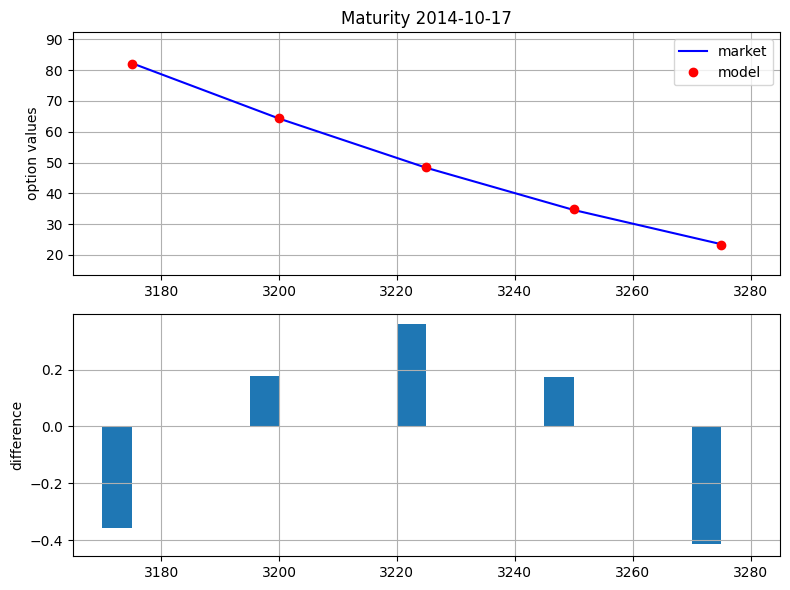

In [30]:
plot_BCC(p0)

There's already a great fit of the model, but let's see if we can improve it in the final step, full calibration.

## **4. Full BCC Calibration**

Now that we have some guidelines on the magnitude of the model parameters, we can perform a full calibration of the model to increase its fit with market data that simultaneously works on the stochastic volatility and the jump components:

In [31]:
p0 = [kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta]

In [32]:
i = 0
min_MSE = 5000


def BCC_error_function(p0):
    """
    Error function for full parameter calibration of BCC model
    """
    global i, min_MSE
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0
    if (
        kappa_v < 0.0
        or theta_v < 0.005
        or sigma_v < 0.0
        or rho < -1.0
        or rho > 1.0
        or v0 < 0.0
        or lamb < 0.0
        or mu < -0.6
        or mu > 0.0
        or delta < 0.0
    ):
        return 5000.0
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 5000.0
    se = []
    for row, option in options.iterrows():
        model_value = BCC_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        se.append((model_value - option["Call"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 100 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    return MSE

In [33]:
def BCC_calibration_full():
    """
    Full calibration of BCC (1997)
    """
    # local, convex minimization for all parameters
    opt = fmin(
        BCC_error_function, p0, xtol=0.000001, ftol=0.000001, maxiter=450, maxfun=750
    )
    return opt

So, let's run our final and full calibration program:

In [34]:
params_BCC = BCC_calibration_full()

   0 | [ 1.03079219e+02  4.05814749e-02  2.88232440e+00 -9.91060575e-01
  9.58976079e-03  9.16066091e-04 -8.95633158e-06  6.29860306e-12] |   0.098 |   0.098
 100 | [ 1.03606920e+02  4.04572998e-02  2.88339490e+00 -9.81712822e-01
  9.65092575e-03  9.35586863e-04 -9.26025115e-06  6.03613709e-12] |   0.096 |   0.096
 200 | [ 1.03058291e+02  4.04697620e-02  2.88816180e+00 -9.74528881e-01
  9.78107276e-03  9.39895507e-04 -9.69597276e-06  5.42939819e-12] |   0.095 |   0.095
 300 | [ 9.95982031e+01  4.16380627e-02  2.87989433e+00 -9.62536930e-01
  6.65120811e-03  4.83411101e-04 -1.96972028e-05  9.41315004e-12] |   0.093 |   0.093
 400 | [ 9.65003791e+01  4.26906290e-02  2.87029275e+00 -9.49966723e-01
  4.06988585e-03  1.78133152e-06 -3.13992983e-05  1.16365060e-11] |   0.091 |   0.091
 500 | [ 9.64848520e+01  4.26922781e-02  2.86965376e+00 -9.51005381e-01
  4.11253341e-03  3.95858024e-08 -3.15793738e-05  1.13856522e-11] |   0.091 |   0.091


/tmp/ipykernel_17/1333146208.py:6: RuntimeWarning: Maximum number of iterations has been exceeded.
  opt = fmin(


In [35]:
kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = params_BCC

Let's also plot together our model option prices under the set of calibrated parameters versus the actual option market prices for the different maturities:

In [36]:
def BCC_calculate_model_values(p0):
    """Calculates all model values given parameter vector p0."""
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0
    values = []
    for row, option in options.iterrows():
        model_value = BCC_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        values.append(model_value)
    return np.array(values)

In [37]:
def plot_BCC_full(p0):
    options["Model"] = BCC_calculate_model_values(p0)
    plt.figure(figsize=(8, 6))
    plt.subplot(211)
    plt.grid()
    plt.title("Maturity %s" % str(options["Maturity"].iloc[0])[:10])
    plt.ylabel("option values")
    plt.plot(options.Strike, options.Call, "b", label="market")
    plt.plot(options.Strike, options.Model, "ro", label="model")
    plt.legend(loc=0)
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(options.Call) - 10,
            max(options.Call) + 10,
        ]
    )
    plt.subplot(212)
    plt.grid()
    wi = 5.0
    diffs = options.Model.values - options.Call.values
    plt.bar(options.Strike.values - wi / 2, diffs, width=wi)
    plt.ylabel("difference")
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(diffs) * 1.1,
            max(diffs) * 1.1,
        ]
    )
    plt.tight_layout()

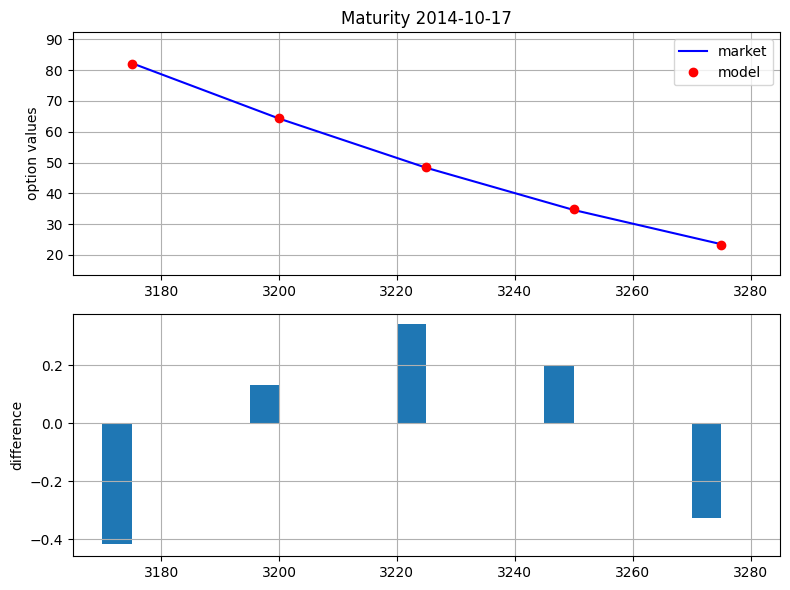

In [38]:
plot_BCC_full(params_BCC)

As you can see, we do a very decent job in matching option market prices.


### Code Task — Implement `augment_quotes(df)` (deterministic, no external deps)

**Goal**  
Given a pandas DataFrame with columns `['S0','K','T','r']`, return a **copy** of the DataFrame with three new columns:

- `dfactor` = `exp(-r*T)`  
- `forward` = `S0 * exp(r*T)`  
- `log_moneyness` = `log(S0 / K)`

**Requirements**
1. Do **not** modify the input DataFrame in place; return a new DataFrame.
2. Use only NumPy/pandas; no other dependencies.
3. Preserve the original row order and existing columns.
4. The returned DataFrame must include the three new columns in any order.

**Function signature**
```python
def augment_quotes(df):
    ...


In [39]:
## Starter code

import numpy as np
import pandas as pd

def augment_quotes(df):
    """
    Return a copy of `df` with three new columns:
        - dfactor = exp(-r*T)
        - forward = S0 * exp(r*T)
        - log_moneyness = log(S0 / K)
    Do not modify the input DataFrame in place.
    """
    # TODO:
    # 1) Make a copy of df
    # 2) Compute dfactor, forward, log_moneyness using vectorized NumPy ops
    # 3) Add the three new columns to the copy and return it
    raise NotImplementedError("Implement augment_quotes as specified.")


## **5. The art of calibration**

Of course, if we had fully calibrated the model for 3 different maturities at the same time, which is very demanding in terms of the actual fit of the model, we would not get such close results. We encourage you to do this and/or repeat it for a different maturity.

This also begs the question of which maturity (or maturities) we should consider when calibrating the model. This is indeed a tricky question. In principle, your pricing horizon will dictate this, but in terms of dynamically hedging your position, you would likely prefer parameter estimates that are close to current situations (i.e., more stable over time).

At this point, you should start realizing that model calibration is as much as art as it is a science. Perfect calibrations are nearly impossible in real life, and there are a bunch questions with no ex-ante clear answers we need to address every time. Here you have some reflections on this:

In [40]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1121447222", h="3298dbabb7", width=700, height=450)


## **6. Conclusion**

In this lesson, we performed a full calibration of the BCC (1997) model. After analyzing the final results of the calibration process, we raised some questions related to the maturity of the market-traded options we should consider for our calibration. In addition, we have primarily focused on model calibration to market prices, but sometimes, it is common to calibrate the model to options' implied volatility, which has certain benefits. We will analyze more deeply these and other questions in future courses.


\
**References**

- Bakshi, Gurdip, et al. "Empirical Performance of Alternative Option Pricing Models." *The Journal of Finance* vol. 52, no. 5, 1997, pp. 2003-2049.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
